# SBA Data Cleaning — EDA and Justification

This notebook **does not perform data cleaning**; cleaning is handled by `scripts/01_clean_sba.py` (the only truth).

This section **justifies why the cleaning decisions are reasonable**: how dirty the original data is, how much is missing, and which columns are leaky.

The graphs and arguments in the "Data Preprocessing" chapter are primarily derived from here.

It reads the **raw `SBAnational.csv`**—dirty values ​​are only visible in the original data.

The cleaned Parquet is read in the last section (health check), which requires running `python scripts/01_clean_sba.py` first.

## 0. Paths and Imports

In [ ]:
%matplotlib inline
import sys
from pathlib import Path

# Compatible with launching from notebooks/ or project root directory
HERE = Path.cwd()
SCRIPTS = HERE / "scripts" if (HERE / "scripts").exists() else HERE.parent / "scripts"
sys.path.append(str(SCRIPTS))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sba_common import RAW_CSV, CLEAN_PARQUET

# Read raw data: Read the known dirty data classifications as strings to make it easier to see the original structure (without setting low_memory=False).
raw = pd.read_csv(RAW_CSV, dtype={
    "RevLineCr": "string", "LowDoc": "string", "NewExist": "string",
    "NAICS": "string", "UrbanRural": "string", "FranchiseCode": "string",
})
print(raw.shape)
raw.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_27864\3629784123.py:16: DtypeWarning: Columns (0: ApprovalFY) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(RAW_CSV, dtype={


(899164, 27)


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,...,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,...,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


## 1. What Does a Dirty Category Look Like? — Demonstrating the Necessity of norm_yn

This is the most valuable part of this notebook: it directly explains why the script maps RevLineCr / LowDoc to clean Y / N / Unknown. Include the following output in the report.

In [ ]:
for col in ["RevLineCr", "LowDoc"]:
    print(f"--- {col} ---")
    print(raw[col].value_counts(dropna=False))
    print()
# You'll see dirty values ​​like 0 / 1 / T / '' (space) mixed in with RevLineCr.
# Without cleaning, the model will treat '0', 'N', and spaces as different categories—that's why norm_yn exists.

--- RevLineCr ---
RevLineCr
N       420288
0       257602
Y       201397
T        15284
<NA>      4528
1           23
R           14
`           11
2            6
C            2
,            1
3            1
7            1
A            1
5            1
.            1
4            1
-            1
Q            1
Name: count, dtype: int64[pyarrow]

--- LowDoc ---
LowDoc
N       782822
Y       110335
<NA>      2582
0         1491
C          758
S          603
A          497
R           75
1            1
Name: count, dtype: int64[pyarrow]



## 2. Target variable MIS_Status — Value imbalance with class

In [ ]:
print(raw["MIS_Status"].value_counts(dropna=False))

# Mapped to is_default using the same caliber as the script.
status = raw["MIS_Status"].astype("string").str.strip().str.upper()
is_default = status.map({"P I F": 0, "PIF": 0, "CHGOFF": 1})

print("\n可映射比例:", round(float(is_default.notna().mean()), 4))   # Lines that cannot be mapped will be removed by the script.
print("违约率   :", round(float(is_default.mean()), 4))              # Too low -> Imbalance needs to be addressed later.

MIS_Status
P I F     739609
CHGOFF    157558
NaN         1997
Name: count, dtype: int64

可映射比例: 0.9978
违约率   : 0.1756


## 3. Missing Columns

Which columns are most frequently missing? This explains why the script retains NaN for certain columns and why NAICS missing columns are handled as a fallback.

ChgOffDate          0.8191
RevLineCr           0.0050
LowDoc              0.0029
DisbursementDate    0.0026
MIS_Status          0.0022
BankState           0.0017
Bank                0.0017
NewExist            0.0002
City                0.0000
State               0.0000
Name                0.0000
dtype: float64


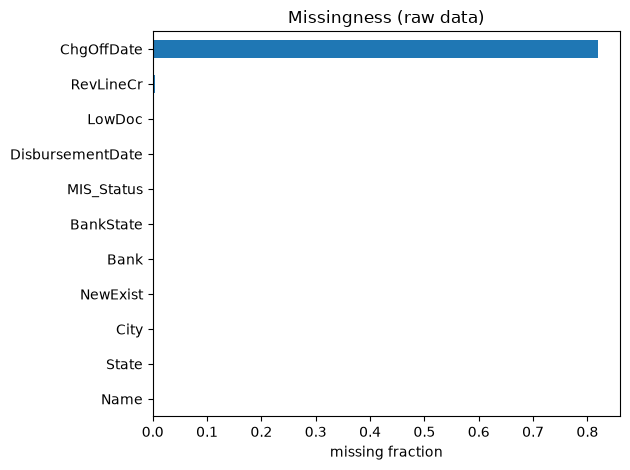

In [5]:
miss = raw.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print(miss.round(4))

if len(miss):
    miss.plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.xlabel("missing fraction"); plt.title("Missingness (raw data)")
    plt.tight_layout(); plt.show()
else:
    print("no missing values")

## 4. Distribution of Amount/Numerical Columns (Including GrAppv == 0 Exception)

The amount column is a **string** containing `$` and commas—this is the reason `clean_money` exists in the script.

First, look at the original structure, then examine the distribution after cleaning.

In [ ]:
# Original text: Note the $ and comma
print(raw[["GrAppv", "SBA_Appv", "DisbursementGross"]].head(), "\n")

def clean_money(s):   # Consistent with 01_clean_sba.py
    return pd.to_numeric(
        s.astype(str).str.replace("$", "", regex=False)
                     .str.replace(",", "", regex=False).str.strip(),
        errors="coerce")

money = pd.DataFrame({c: clean_money(raw[c]) for c in ["GrAppv", "SBA_Appv", "DisbursementGross"]})
money["Term"] = pd.to_numeric(raw["Term"], errors="coerce")
money.describe()

         GrAppv      SBA_Appv DisbursementGross
0   $60,000.00    $48,000.00        $60,000.00 
1   $40,000.00    $32,000.00        $40,000.00 
2  $287,000.00   $215,250.00       $287,000.00 
3   $35,000.00    $28,000.00        $35,000.00 
4  $229,000.00   $229,000.00       $229,000.00  



,GrAppv,SBA_Appv,DisbursementGross,Term
count,8.991640e+05,8.991640e+05,8.991640e+05,899164.000000
mean,1.926870e+05,1.494888e+05,2.011540e+05,110.773078
std,2.832634e+05,2.284146e+05,2.876408e+05,78.857305
min,2.000000e+02,1.000000e+02,0.000000e+00,0.000000
25%,3.500000e+04,2.125000e+04,4.200000e+04,60.000000
50%,9.000000e+04,6.125000e+04,1.000000e+05,84.000000
75%,2.250000e+05,1.750000e+05,2.380000e+05,120.000000
max,5.472000e+06,5.472000e+06,1.144632e+07,569.000000


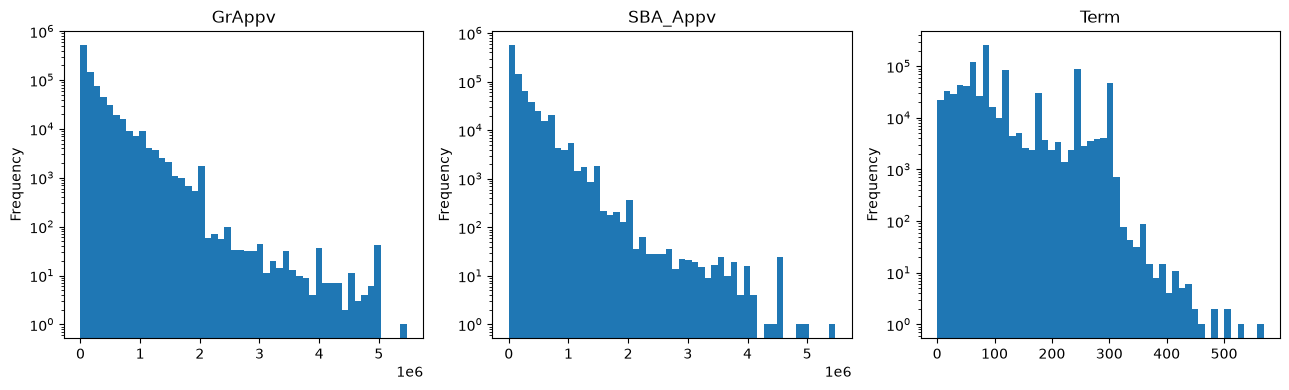

GrAppv == 0 的异常贷款数: 0
-> 脚本里用 zero_appv_flag 标记，sba_guar_ratio 在此保留 NaN，不被中位数抹平


In [ ]:
# The amount is highly skewed to the right; use a log histogram to observe this.
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, c in zip(ax, ["GrAppv", "SBA_Appv", "Term"]):
    money[c].dropna().plot(kind="hist", bins=50, ax=a, logy=True)
    a.set_title(c)
plt.tight_layout(); plt.show()

# Abnormal loans with GrAppv == 0
n_zero = int((money["GrAppv"] == 0).sum())
print(f"Abnormal loan count with GrAppv == 0: {n_zero}")
print("-> The script uses the `zero_appv_flag` flag to preserve `sba_guar_ratio` as NaN, preventing it from being flattened by the median.")

## 5. Leakage/Passage Feature Argumentation 

`ChgOffPrinGr` (offsetting amount) / `BalanceGross` (balance) / `ChgOffDate` are only available after the loan is **completed**;

`DisbursementGross` is only known **after the loan is disbursed** (not available in pre-approval scoring scenarios). Using them to predict default = leakage.

In [ ]:
# 演示 ChgOffPrinGr 几乎等同于标签：只有违约(CHGOFF)的贷款才有冲销额
chg = clean_money(raw["ChgOffPrinGr"])
has_chgoff = chg.fillna(0) > 0
print("For samples where ChgOffPrinGr > 0, the MIS_Status distribution is：")
print(status[has_chgoff].value_counts(dropna=False))
print("\n=> ChgOffPrinGr is basically only non-zero when there is a default, which means feeding the answer to the model -> it must be discarded.")
print("   Similarly, BalanceGross / ChgOffDate (results leaked), DisbursementGross (results only available after approval).")

ChgOffPrinGr > 0 的样本，其 MIS_Status 分布：
MIS_Status
CHGOFF    156871
P I F       4884
<NA>         257
Name: count, dtype: int64[pyarrow]

=> ChgOffPrinGr 基本只在违约时非零，等于把答案喂给模型 -> 必须丢
   同理 BalanceGross / ChgOffDate（结果泄露），DisbursementGross（审批后才有）


## 6. Health Check (Run `python scripts/01_clean_sba.py` first, then run this section)

Read the cleaned Parquet and check the script output: Has the leaking column been deleted? Has the dirty value been cleared? Are the new features present?

In [ ]:
clean = pd.read_parquet(CLEAN_PARQUET)
print("shape:", clean.shape)

leak = [c for c in ["ChgOffPrinGr", "BalanceGross", "DisbursementGross", "MIS_Status",
                    "ChgOffDate", "NAICS"] if c in clean.columns]
print("\nColumns that should have been deleted but still exist:", leak if leak else "None (all have been deleted)")

print("\nRevLineCr After cleaning:", clean["RevLineCr"].value_counts(dropna=False).to_dict())
print("LowDoc    After cleaning:", clean["LowDoc"].value_counts(dropna=False).to_dict())

new_feats = [c for c in ["naics_sector", "sba_guar_ratio", "zero_appv_flag", "term_years",
                         "is_franchise", "same_state_bank", "recession_0709", "end_year"]
             if c in clean.columns]
print("\nNew features:", new_feats)
print("Default rate:", round(float(clean["is_default"].mean()), 4))

shape: (897167, 23)

应已删除却仍存在的列: 无（全部已删除）

RevLineCr 清洗后: {'N': 419252, 'Unknown': 277255, 'Y': 200660}
LowDoc    清洗后: {'N': 780997, 'Y': 110171, 'Unknown': 5999}

新造特征: ['naics_sector', 'sba_guar_ratio', 'zero_appv_flag', 'term_years', 'is_franchise', 'same_state_bank', 'recession_0709', 'end_year']
违约率: 0.1756
